**Install Libraries**

In [58]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

**Load the Website**

In [19]:
url="https://books.toscrape.com/"

response=requests.get(url)

print(response.status_code)

200


**Parse HTML**

In [20]:
soup = BeautifulSoup(response.content, "html.parser")
print(soup.title.text)


    All products | Books to Scrape - Sandbox



**Find All Books on the Page**

In [21]:
books = soup.find_all("article", class_="product_pod")

len(books)

20

**Inspect One Book**

In [22]:
book = books[0]

print(book.prettify())

<article class="product_pod">
 <div class="image_container">
  <a href="catalogue/a-light-in-the-attic_1000/index.html">
   <img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/>
  </a>
 </div>
 <p class="star-rating Three">
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
 </p>
 <h3>
  <a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">
   A Light in the ...
  </a>
 </h3>
 <div class="product_price">
  <p class="price_color">
   £51.77
  </p>
  <p class="instock availability">
   <i class="icon-ok">
   </i>
   In stock
  </p>
  <form>
   <button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">
    Add to basket
   </button>
  </form>
 </div>
</article>



**Extract the Information**

In [32]:
book_list=[]
for book in books:
    title=book.h3.a["title"]
    price=(
        book.find("p", class_="price_color").get_text(strip=True).replace("£", ""))
    rating=book.find("p")["class"][1]

    availability=(
        book.find("p", class_="instock availability").get_text(strip=True)
    )
    link=urljoin(url, book.h3.a["href"])

    book_list.append({
        "Title": title,
        "Price": float(price),
        "Rating": rating,
        "Availability": availability,
        "Link": link
    })

In [33]:
df=pd.DataFrame(book_list)
df.head()

,Title,Price,Rating,Availability,Link
0,A Light in the Attic,51.77,Three,In stock,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,53.74,One,In stock,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,50.10,One,In stock,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,47.82,Four,In stock,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock,https://books.toscrape.com/catalogue/sapiens-a...


In [37]:
df.shape

(20, 5)

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         20 non-null     str    
 1   Price         20 non-null     float64
 2   Rating        20 non-null     str    
 3   Availability  20 non-null     str    
 4   Link          20 non-null     str    
dtypes: float64(1), str(4)
memory usage: 3.5 KB


In [39]:
df.describe()

,Price
count,20.000000
mean,38.048500
std,15.135231
min,13.990000
25%,22.637500
50%,41.380000
75%,51.865000
max,57.250000


**Scrape All 50 Page**

In [43]:
all_books = []

base_url = "https://books.toscrape.com/"

for page in range(1, 51):

    if page == 1:
        url = base_url
    else:
        url = f"{base_url}catalogue/page-{page}.html"

    print(f"Scraping Page {page}")

    response = requests.get(url)
    soup = BeautifulSoup(response.content, "html.parser")

    books = soup.find_all("article", class_="product_pod")

    for book in books:

        title = book.h3.a["title"]

        price = (
            book.find("p", class_="price_color")
            .get_text(strip=True)
            .replace("£", "")
            .replace("Â£", "")
        )

        rating = book.find("p")["class"][1]

        availability = (
            book.find("p", class_="instock availability")
            .get_text(strip=True)
        )

        link = urljoin(url, book.h3.a["href"])

        all_books.append({
            "Title": title,
            "Price": float(price),
            "Rating": rating,
            "Availability": availability,
            "Link": link
        })

Scraping Page 1
Scraping Page 2
Scraping Page 3
Scraping Page 4
Scraping Page 5
Scraping Page 6
Scraping Page 7
Scraping Page 8
Scraping Page 9
Scraping Page 10
Scraping Page 11
Scraping Page 12
Scraping Page 13
Scraping Page 14
Scraping Page 15
Scraping Page 16
Scraping Page 17
Scraping Page 18
Scraping Page 19
Scraping Page 20
Scraping Page 21
Scraping Page 22
Scraping Page 23
Scraping Page 24
Scraping Page 25
Scraping Page 26
Scraping Page 27
Scraping Page 28
Scraping Page 29
Scraping Page 30
Scraping Page 31
Scraping Page 32
Scraping Page 33
Scraping Page 34
Scraping Page 35
Scraping Page 36
Scraping Page 37
Scraping Page 38
Scraping Page 39
Scraping Page 40
Scraping Page 41
Scraping Page 42
Scraping Page 43
Scraping Page 44
Scraping Page 45
Scraping Page 46
Scraping Page 47
Scraping Page 48
Scraping Page 49
Scraping Page 50


**Create the DataFrame**

In [44]:
df = pd.DataFrame(all_books)

df.head()

,Title,Price,Rating,Availability,Link
0,A Light in the Attic,51.77,Three,In stock,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,53.74,One,In stock,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,50.10,One,In stock,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,47.82,Four,In stock,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock,https://books.toscrape.com/catalogue/sapiens-a...


In [45]:
df.shape

(1000, 5)

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         1000 non-null   str    
 1   Price         1000 non-null   float64
 2   Rating        1000 non-null   str    
 3   Availability  1000 non-null   str    
 4   Link          1000 non-null   str    
dtypes: float64(1), str(4)
memory usage: 175.9 KB


In [52]:
df.isnull().sum()

Title           0
Price           0
Rating          0
Availability    0
Link            0
dtype: int64

In [53]:
df.duplicated().sum()

np.int64(0)

**Convert ratings to numbers**

In [54]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_map)

In [55]:
df.describe()

,Price,Rating
count,1000.00000,1000.000000
mean,35.07035,2.923000
std,14.44669,1.434967
min,10.00000,1.000000
25%,22.10750,2.000000
50%,35.98000,3.000000
75%,47.45750,4.000000
max,59.99000,5.000000


**Rating Distribution**

In [56]:
rating_count = df["Rating"].value_counts().sort_index()

rating_count

Rating
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64

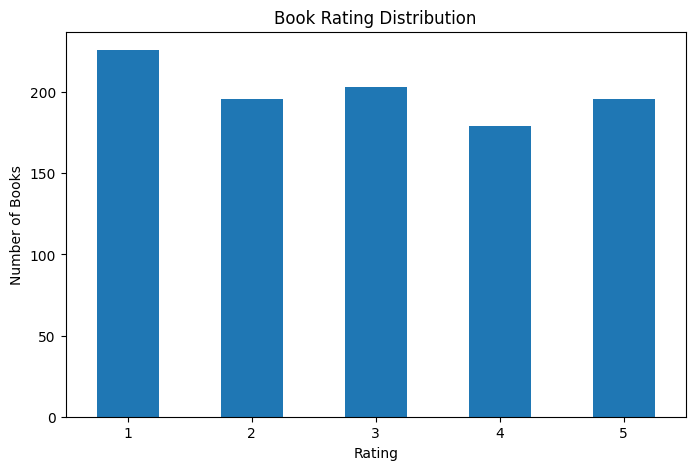

In [70]:
plt.figure(figsize=(8,5))

rating_count.plot(kind="bar")

plt.title("Book Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.xticks(rotation=0)
plt.savefig("Book Rating Distribution.png", dpi=300)
plt.show()

**Price Distribution**

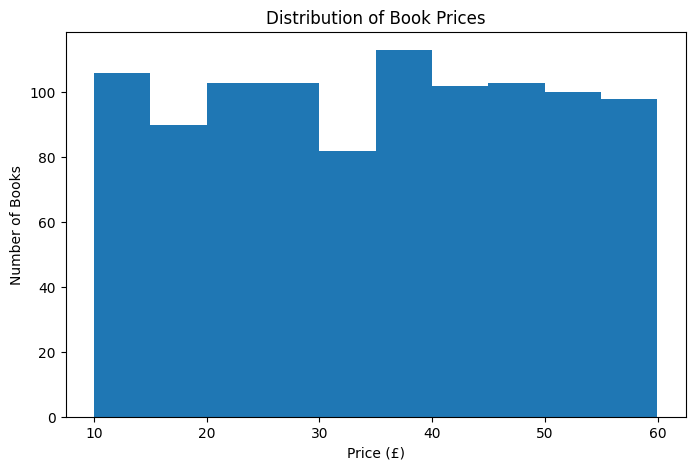

In [71]:
plt.figure(figsize=(8,5))

plt.hist(df["Price"], bins=10)

plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.savefig("Distribution of Book Prices.png", dpi=300)
plt.show()

**Top 10 Most Expensive Books**

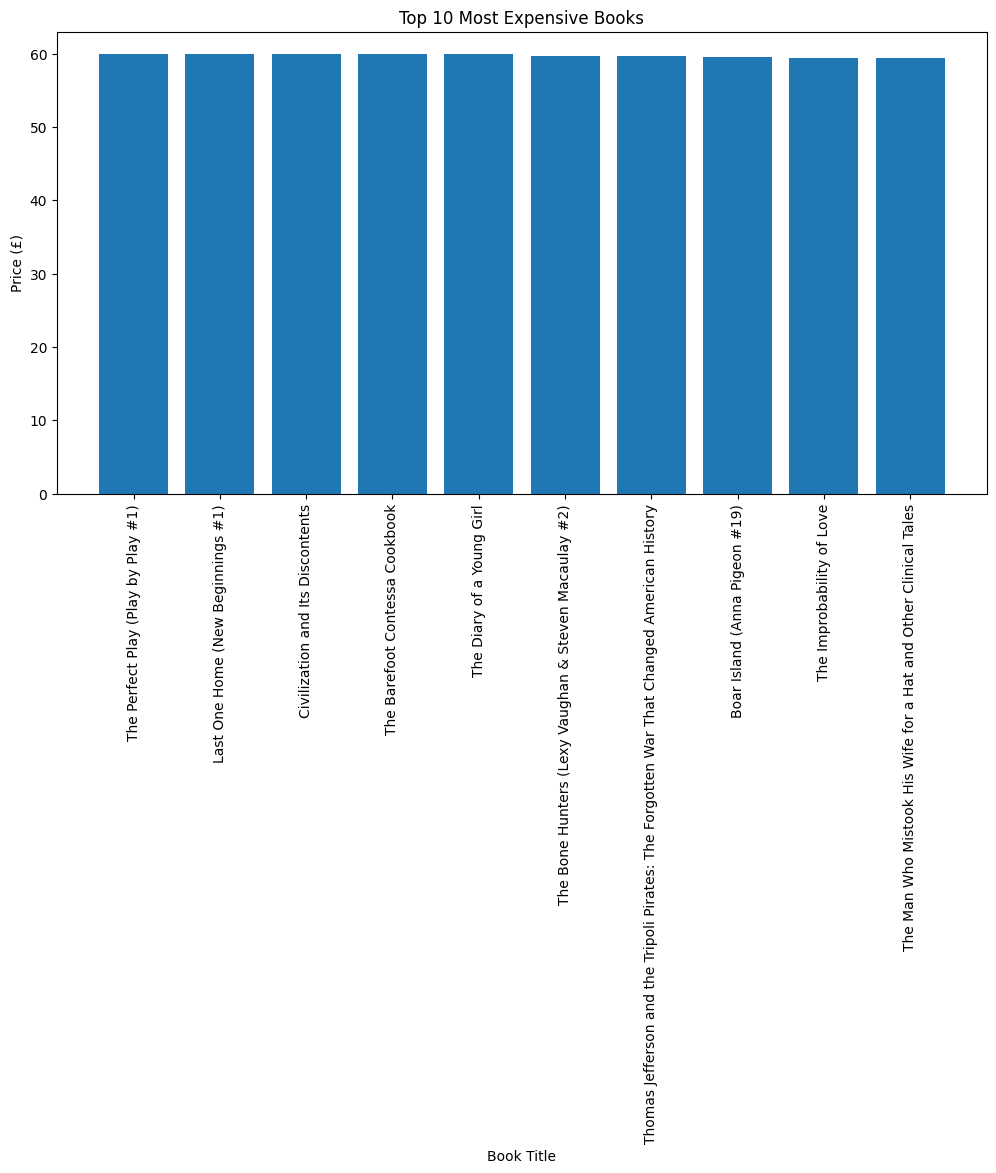

In [72]:
top10 = df.nlargest(10, "Price")

plt.figure(figsize=(12,6))

plt.bar(top10["Title"], top10["Price"])

plt.title("Top 10 Most Expensive Books")
plt.xlabel("Book Title")
plt.ylabel("Price (£)")

plt.xticks(rotation=90)
plt.savefig("Top 10 Most Expensive Books.png", dpi=300)
plt.show()

**Average Price by Rating**

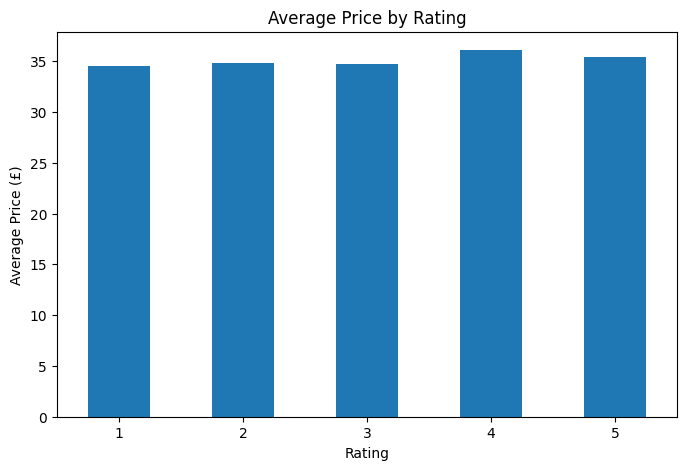

In [73]:
avg_price = df.groupby("Rating")["Price"].mean()

plt.figure(figsize=(8,5))

avg_price.plot(kind="bar")

plt.title("Average Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price (£)")

plt.xticks(rotation=0)
plt.savefig("Average Price by Rating.png", dpi=300)
plt.show()

**Box Plot of Prices**

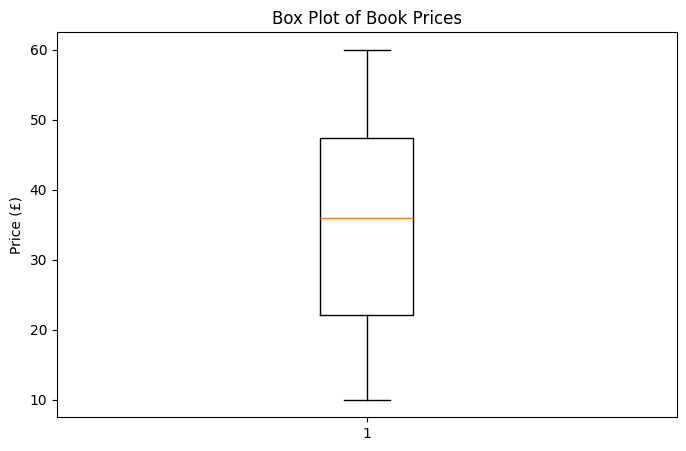

In [74]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Price"])

plt.title("Box Plot of Book Prices")
plt.ylabel("Price (£)")
plt.savefig("Box Plot of Book Prices.png", dpi=300)
plt.show()

**Price Category Distribution**

In [64]:
bins = [0,20,40,60]
labels = ["Low","Medium","High"]

df["Price Category"] = pd.cut(df["Price"],
                              bins=bins,
                              labels=labels)

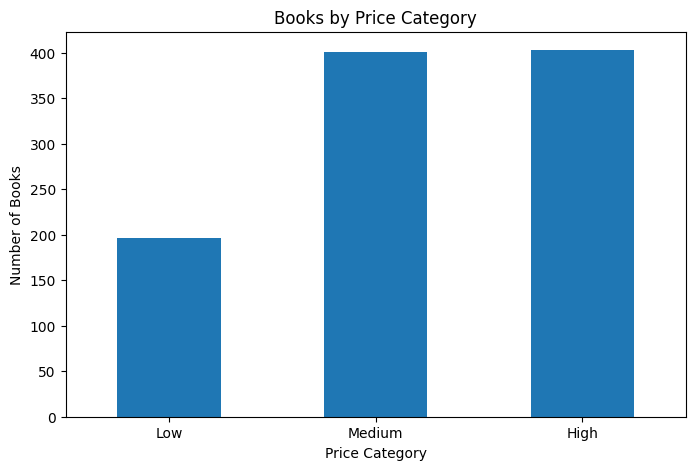

In [75]:
category_count = df["Price Category"].value_counts().sort_index()

plt.figure(figsize=(8,5))

category_count.plot(kind="bar")

plt.title("Books by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Number of Books")

plt.xticks(rotation=0)
plt.savefig("Books by Price Category.png", dpi=300)
plt.show()

In [66]:
df[["Price","Rating"]].corr()

,Price,Rating
Price,1.000000,0.028166
Rating,0.028166,1.000000


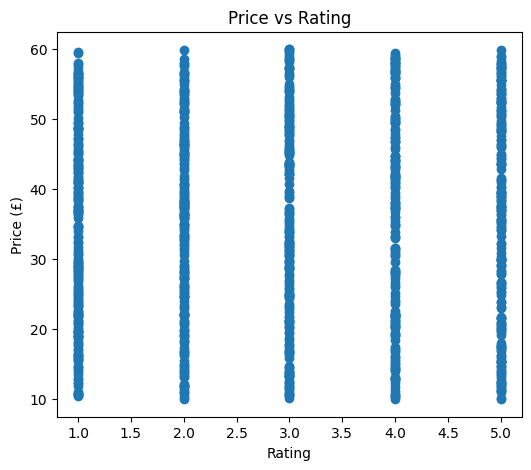

In [76]:
plt.figure(figsize=(6,5))

plt.scatter(df["Rating"], df["Price"])

plt.title("Price vs Rating")
plt.xlabel("Rating")
plt.ylabel("Price (£)")
plt.savefig("Price vs Rating.png", dpi=300)
plt.show()

In [68]:
top_rated = df[df["Rating"] == 5]

top_rated.head(10)

,Title,Price,Rating,Availability,Link,Price Category
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,https://books.toscrape.com/catalogue/sapiens-a...,High
12,Set Me Free,17.46,5,In stock,https://books.toscrape.com/catalogue/set-me-fr...,Low
13,Scott Pilgrim's Precious Little Life (Scott Pi...,52.29,5,In stock,https://books.toscrape.com/catalogue/scott-pil...,High
14,Rip it Up and Start Again,35.02,5,In stock,https://books.toscrape.com/catalogue/rip-it-up...,Medium
23,Chase Me (Paris Nights #2),25.27,5,In stock,https://books.toscrape.com/catalogue/chase-me-...,Medium
24,Black Dust,34.53,5,In stock,https://books.toscrape.com/catalogue/black-dus...,Medium
28,Worlds Elsewhere: Journeys Around Shakespeare’...,40.30,5,In stock,https://books.toscrape.com/catalogue/worlds-el...,High
30,The Four Agreements: A Practical Guide to Pers...,17.66,5,In stock,https://books.toscrape.com/catalogue/the-four-...,Low
32,The Elephant Tree,23.82,5,In stock,https://books.toscrape.com/catalogue/the-eleph...,Medium
34,Sophie's World,15.94,5,In stock,https://books.toscrape.com/catalogue/sophies-w...,Low


In [69]:
df.to_csv("books_analysis_final.csv", index=False)

**Key Insights**
1. A total of 1,000 books were successfully scraped from the website.
2. Book prices range from the minimum to the maximum values shown in the summary statistics.
3. The majority of books fall into the Medium price category.
4. Some rating levels are more common than others, indicating an uneven distribution of ratings.
5. The top 10 most expensive books are significantly higher in price than the average.
6. There is little to no strong correlation between book price and rating.
7. Most books are marked as In Stock.
8. The dataset contains no missing values, making it suitable for analysis.
9. The dataset contains no duplicate records after cleaning.
10.Converting ratings from text to numeric made quantitative analysis easier.